In [1]:
import sys
sys.path.append("../ext/equi-rl-for-pomdps")
from rgbd_sym.api import make_env
import argparse
import numpy as np
from rgbd_sym.tool.plt import use_backend

from rgbd_sym.tool.sym import local_sym_step
from rgbd_sym.tool.depth import get_intrinsic_matrix, projection_matrix_to_K
import time
# use_backend('tkagg')

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
sym_step_idx = 5
size = 84

args = {}

args['action_delta_pos'] = 0.05
args['action_delta_rot'] = np.pi / 8
args['pc_x_center'] = 0.0
args['pc_y_center'] = 0.0
args['pc_z_center'] = 0.75
args['pc_range'] = 0.8
args['voxel_res'] = 84
args['depth_real_min'] = 0
args['depth_real_max'] = 1
args['depth_upsample'] = 6
args['out_image_type'] = 'depth'
args['out_background_encoding'] = 255

In [3]:
from matplotlib.pyplot import imshow, subplot, axis, cm, show
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
# %matplotlib inline


def plot_img(imgs_2d, big_axes_title=[],figsize=None):
    plt_cnt = 0
    row_size = np.max(np.array([len(k) for k in imgs_2d]))
    fig, big_axes = plt.subplots(nrows=len(imgs_2d), ncols=1, sharey=True)
    for row, big_ax in enumerate(big_axes, start=1):
        big_ax.set_title(big_axes_title[row-1], fontsize=16)

        # Turn off axis lines and ticks of the big subplot 
        # obs alpha is 0 in RGBA string!
        big_ax.tick_params(labelcolor=(1.,1.,1., 0.0), top='off', bottom='off', left='off', right='off')
        # removes the white frame
        big_ax._frameon = False
    for k, im in enumerate(imgs_2d):
        for i, img in enumerate(im):
            plt_cnt= row_size * k + i +1
            ax = subplot(len(imgs_2d), row_size, plt_cnt)
            if isinstance(img, dict):
                imshow(img['image'])
                if "title" in img:
                    plt.title(img['title'])
            else:
                imshow(img)
            plt.colorbar()
        # if i == (len(im) -1):
        #     ax.set_title(f"{titles[0]} step {i+1}, backtrace image!")
        # else:
        #     ax.set_title(f"{titles[k]} step {i+1}")
    # if not  no_show:
    show()


In [4]:
def plotline(
    points_mats,
    range_min,
    range_max,
    color="gray",
    legend_txt=None,
    alpha=0.4,
    linewidth=1,
    elev=0,
    azim=90,
    roll=90,
):
    fig = plt.figure()
    ax = plt.axes(projection="3d")
    ax.axes.set_xlim3d(left=range_min[0], right=range_max[0])
    ax.axes.set_ylim3d(bottom=range_min[1], top=range_max[1])
    ax.axes.set_zlim3d(bottom=range_min[2], top=range_max[2])
    # ax.view_init(elev=elev, azim=azim, roll=roll)
    ax.set_xlabel("$X$")
    ax.set_ylabel("$Y$")
    ax.set_ylabel("$Z$")
    if legend_txt == None:
        ax.plot3D(
            points_mat[:, 0].tolist(),
            points_mat[:, 1].tolist(),
            points_mat[:, 2].tolist(),
            color,
            alpha=alpha,
            linewidth=linewidth,
        )
    else:
        ax.plot3D(
            points_mat[:, 0].tolist(),
            points_mat[:, 1].tolist(),
            points_mat[:, 2].tolist(),
            color,
            label=legend_txt,
            alpha=alpha,
            linewidth=linewidth,
        )

    plt.legend(loc="best")
    plt.show()


from rgbd_sym.tool.common import getT, TxT


def action2transformdict(
    action,
    delta_pos,
    delta_rot,
    reverse=False,
):
    transform_dict = {}
    # 'dpos': 0.05, 'drot': np.pi/8
    # rot_scale = np.pi/8
    # transl_scale = 0.05 * 0.27
    sign = -1 if reverse else 1
    transform_dict["gripper"] = getT(
        [0, 0, 0],
        [0, 0, action[4] * sign * delta_rot],
        rot_type="euler",
        euler_Degrees=False,
    )
    transform_dict["object1"] = getT(
        [
            -delta_pos * action[1] * sign,
            -delta_pos * action[2] * sign,
            delta_pos * action[3] * sign,
        ],
        [0, 0, 0],
        rot_type="euler",
    )
    transform_dict["object2"] = transform_dict["object1"].copy()
    return transform_dict


def actions2Ts(
    actions,
    action_delta_pos,
    action_delta_rot,
    reverse=True,
):
    trajTs = []
    _actions = [v for v in reversed(actions)] if reverse else actions
    _actions = [np.zeros(5)] + _actions
    T_dict = None
    for action in _actions:
        delta_T_dict = action2transformdict(
            action,
            reverse=reverse,
            delta_pos=action_delta_pos,
            delta_rot=action_delta_rot,
        )
        if T_dict is None:
            T_dict = delta_T_dict
        else:
            T_dict = {k: TxT([delta_T_dict[k], v]) for k, v in T_dict.items()}
        trajTs.append(T_dict)

    trajTs = [v["object2"] for v in trajTs]
    return trajTs

pybullet build time: Nov 28 2023 23:52:03


robot id None
K [[59.98221231  0.         42.        ]
 [ 0.         59.98221231 42.        ]
 [ 0.          0.          1.        ]]


/home/ben/miniconda3/envs/rgbd-sym/lib/python3.9/site-packages/gym/spaces/box.py:84: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


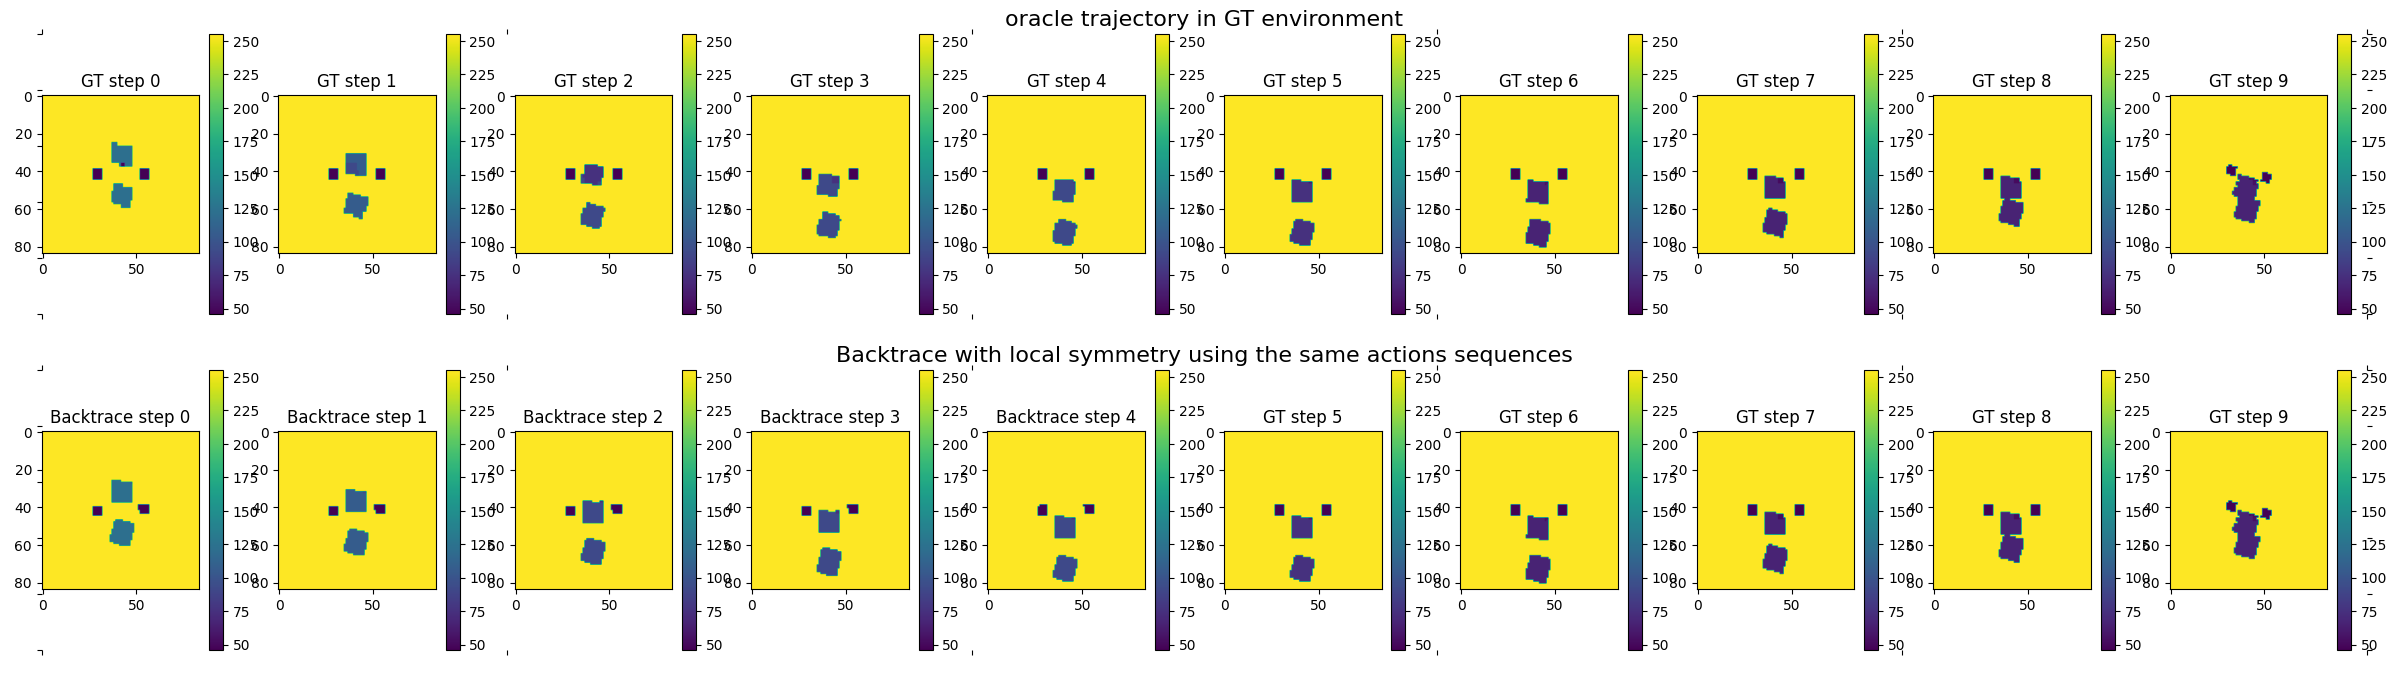

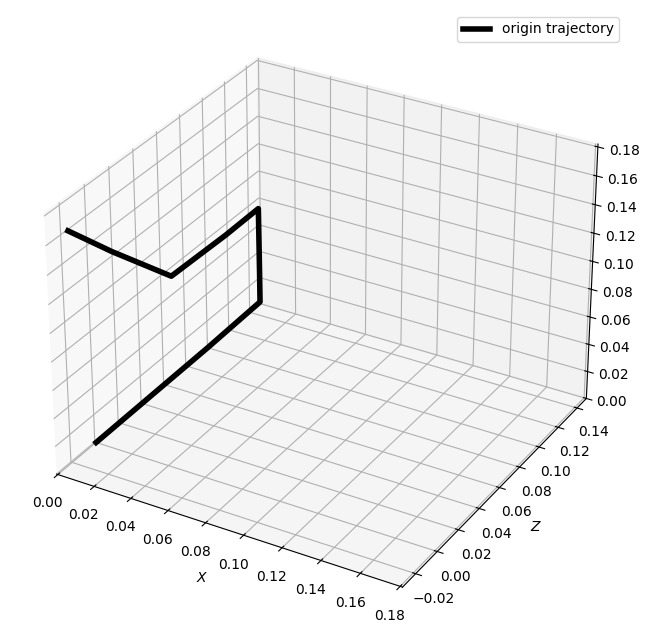

In [5]:
env, env_config = make_env(tags=['block_pull', "no_clutch"], seed=0)
obs = env.reset()
proj_matrix = env.get_projection_matrix()
K = projection_matrix_to_K(proj_matrix, image_size=size)
print("K", K)
# generate ground truth trajectory
origin_actions = []
imgs1_meta = [obs]
done = False
while not done:
    action = env.pull_movable()
    origin_actions.append(action)
    obs, reward, done, info = env.step(action)
    imgs1_meta.append(obs)
origin_depth_image_traj = []
for i in range(len(imgs1_meta)):
    origin_depth_image_traj.append(local_sym_step(imgs1_meta[i]['depth'],
                                                  imgs1_meta[i]['mask'], [],
                                                  K=K,
                                                  **args)[0])


# generate symmetric trajectry with backtrace
start_depth_dict = imgs1_meta[sym_step_idx]['depth']
start_mask_dict = imgs1_meta[sym_step_idx]['mask']
sym_actions = [a for a in origin_actions[:sym_step_idx]]
start = time.time()

sym_depth_image_traj = local_sym_step(
    start_depth_dict, 
    start_mask_dict, 
    sym_actions, 
    K=K, 
    reverse=True,
    **args)

sym_depth_image_traj.extend(origin_depth_image_traj[sym_step_idx+1:])
sym_actions.extend(origin_actions[sym_step_idx:])
imgss = []
imgss.append([{"image": v, "title": f"GT step {i}"} for i, v in enumerate(origin_depth_image_traj)])
imgss.append([{"image": v, "title": f"GT step {i}" if i>=sym_step_idx else f"Backtrace step {i}"} for i, v in enumerate(sym_depth_image_traj)])
plt.rcParams['figure.figsize'] = [30, 8]
plot_img(imgss, big_axes_title=["oracle trajectory in GT environment", "Backtrace with local symmetry using the same actions sequences",])

trajTs = actions2Ts(
    origin_actions,
    action_delta_pos=args["action_delta_pos"],
    action_delta_rot=args["action_delta_rot"],
    reverse=True,
)
points_mat = np.array([[t[0][3], t[1][3], t[2][3]] for t in trajTs])
pc_min = np.min(points_mat, axis=0)
pc_max = np.max(points_mat, axis=0)
pc_range = np.max(pc_max - pc_min)

plotline(
    points_mat,
    color="k",
    legend_txt="origin trajectory",
    linewidth=4,
    alpha=1,
    elev=0,
    azim=-90,
    roll=180,
    range_min=pc_min,
    range_max=pc_min + pc_range,
)

[array([ 1.        ,  0.22190205, -1.        , -1.        , -0.01591283]), array([ 1.        ,  0.01055113, -1.        , -1.        ,  0.03969749]), array([ 1.        ,  0.00519506, -1.        , -0.03877851,  0.03622442]), array([ 1.00000000e+00,  5.80779480e-03, -6.20939028e-01, -3.38882208e-04,
        3.69848250e-02]), array([ 1.        ,  0.00505584, -0.01778866, -1.        ,  0.03315243])]
[array([1.        , 0.66523969, 0.5563135 , 0.7400243 , 0.95723668]), array([ 1.        ,  0.59831713, -0.07704128,  0.56105835, -0.76345115]), array([ 1.        ,  0.27984204, -0.71329343,  0.88933783,  0.04369664]), array([ 1.        , -0.17067612, -0.47088878,  0.54846738, -0.08769934]), array([ 1.        ,  0.1368679 , -0.9624204 ,  0.23527099,  0.22419145])]
[array([ 1.        ,  0.23386799,  0.88749616,  0.3636406 , -0.2809842 ]), array([ 1.        , -0.12593609,  0.39526239, -0.87954906,  0.33353343]), array([ 1.        ,  0.34127574, -0.57923488, -0.7421474 , -0.3691433 ]), array([ 1.   

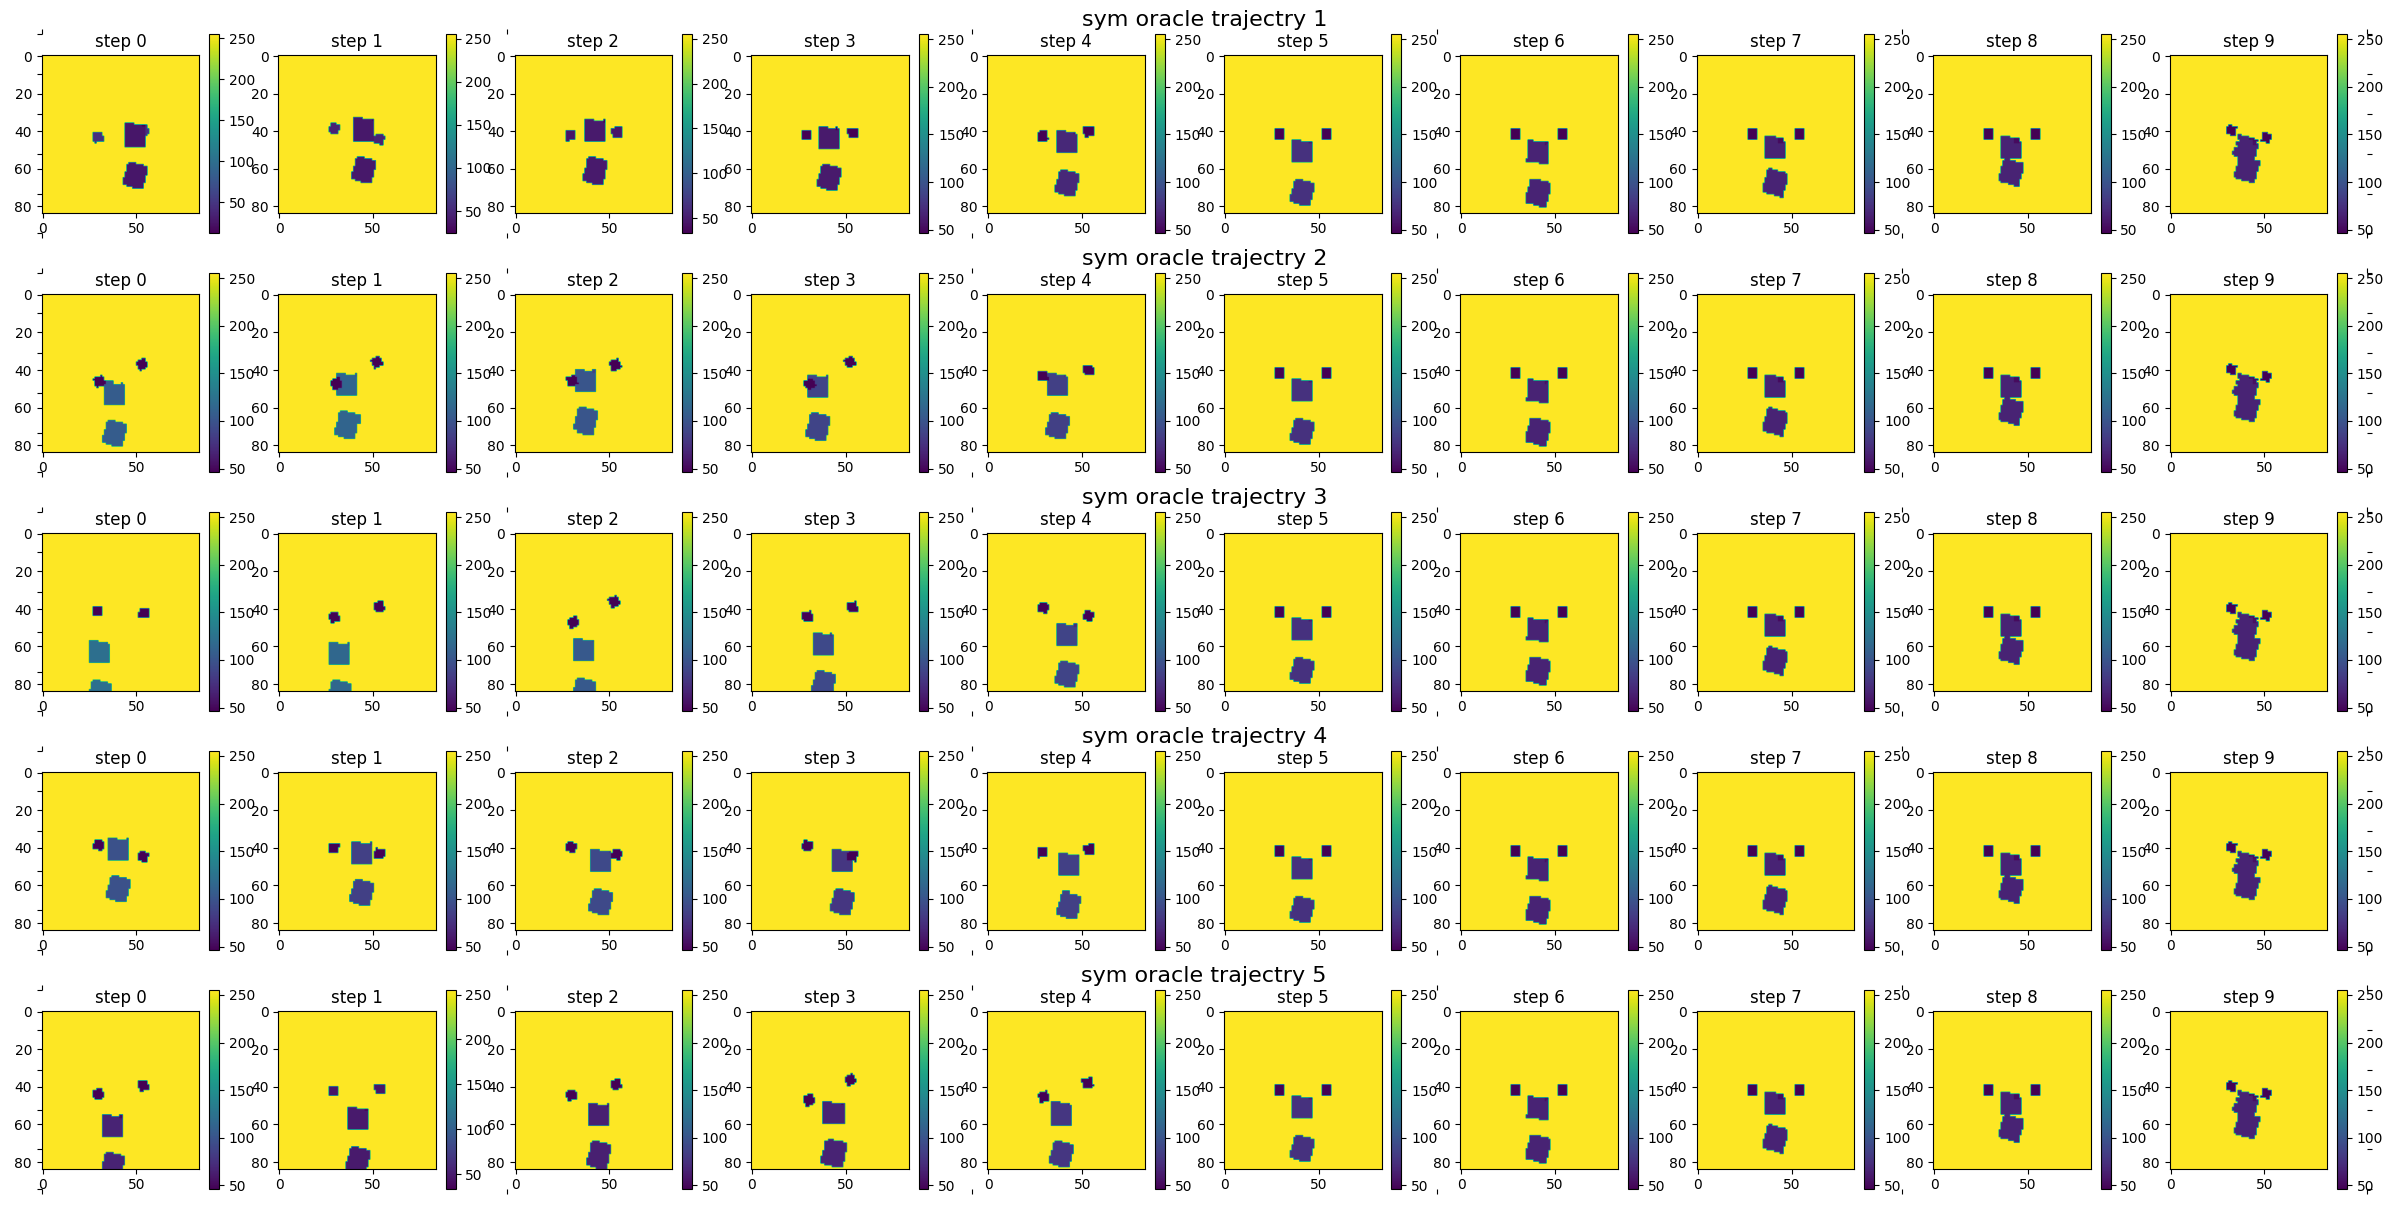

In [6]:
traj_nums = 5
sym_trajs = []
sym_actions_fulls = []
for i in range(traj_nums):

    sym_actions = [a for a in origin_actions[:sym_step_idx]]
    sym_actions_full = sym_actions
    sym_actions_full.extend(origin_actions[sym_step_idx:])
    sym_actions_fulls.append(sym_actions_full)
    print(sym_actions)
    for k in range(len(sym_actions)):
        # sym_actions[0] = np.random.uniform(-1,1)
        sym_actions[k][1] = np.random.uniform(-1, 1)
        sym_actions[k][2] = np.random.uniform(-1, 1)
        sym_actions[k][3] = np.random.uniform(-1, 1)
        sym_actions[k][4] = np.random.uniform(-1, 1)

    sym_depth_image_traj3 = local_sym_step(
        start_depth_dict, start_mask_dict, sym_actions, K=K, reverse=True, **args
    )
    sym_depth_image_traj3.extend(origin_depth_image_traj[sym_step_idx + 1 :])
    sym_trajs.append(
        [
            {"image": v, "title": f"step {j}"}
            for j, v in enumerate(sym_depth_image_traj3)
        ]
    )
plt.rcParams["figure.figsize"] = [30, 15]
plot_img(
    sym_trajs, big_axes_title=[f"sym oracle trajectry {i+1}" for i in range(traj_nums)]
)


points_mats = []
pc_mins = []
pc_maxs = []

for a in sym_actions_fulls:
    trajTs = actions2Ts(
        a,
        action_delta_pos=args["action_delta_pos"],
        action_delta_rot=args["action_delta_rot"],
        reverse=True,
    )
    points_mat = np.array([[t[0][3], t[1][3], t[2][3]] for t in trajTs])
    points_mats.append(points_mat)
    pc_min = np.min(points_mat, axis=0)
    pc_max = np.max(points_mat, axis=0)
    pc_mins.append(pc_min)
    pc_maxs.append(pc_max)

pc_min = np.min(np.array(pc_mins), axis=0)
pc_max = np.max(np.array(pc_mins), axis=0)
pc_range = np.max(pc_max - pc_min)

fig = plt.figure()
ax = plt.axes(projection="3d")
plotline(
    points_mat,
    color="k",
    legend_txt="origin trajectory",
    linewidth=4,
    alpha=1,
    elev=0,
    azim=-90,
    roll=180,
    range_min=pc_min,
    range_max=pc_min + pc_range,
)